# ECCO-DarwinDiff — Micro Prototype Recovery Demo

This notebook validates the differentiable scaffold end-to-end on a 1D toy problem before we scale to real Darwin equations. It runs entirely on the local GPU.

**What's being tested:** PyTorch autograd flows through hand-coded numerical integration of a 1D reaction-diffusion equation, a small MLP predicts a spatially-varying loss-rate parameter $\lambda(z)$, and gradient descent recovers a known synthetic profile. If recovery succeeds within tolerance, the same scaffold transfers to real Darwin biogeochemistry once the equation subset and parameter targets are locked with the domain advisor — only the physics module is swapped, the MLP and recovery loop stay the same.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from darwindiff.prototype.parameter_mlp import ParameterMLP
from darwindiff.prototype.physics import integrate
from darwindiff.prototype.synthetic_data import generate_synthetic_observations
from darwindiff.prototype.train import train_recovery

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}")
print(
    f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}"
)

PyTorch 2.11.0+cu128
Device: NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Set up the 1D ocean column

50 vertical levels from the surface to 500 m. Initial concentration $u(z, 0) = 1$. The fixed source $S(z)$ is surface-weighted (exponential decay with depth), standing in for sinking and remineralisation patterns in real biogeochemistry.

In [2]:
Nz = 50
z = torch.linspace(0.0, 500.0, Nz)
u0 = torch.ones(Nz)
S_z = 0.1 * torch.exp(-z / 200.0)

kappa = 0.01     # vertical diffusion coefficient
dz = 10.0        # spatial grid spacing (m)
dt = 1.0         # time step
n_steps = 200    # integration length

print(f"Column: {Nz} levels, depth 0\u2013{z[-1].item():.0f} m, dz = {dz} m")
print(f"Integration: {n_steps} steps, dt = {dt}")

Column: 50 levels, depth 0–500 m, dz = 10.0 m
Integration: 200 steps, dt = 1.0


## 2. Generate synthetic observations from a known $\lambda(z)$

We pick a ground-truth depth-dependent loss rate (high near surface, exponential decay), run the simulator forward to produce a final concentration profile, and add small Gaussian noise. The MLP later has to recover $\lambda(z)$ from these observations alone — it never sees the ground truth during training.

In [3]:
u_obs, lambda_true = generate_synthetic_observations(
    z=z, u0=u0, S_z=S_z,
    kappa=kappa, dz=dz, dt=dt, n_steps=n_steps,
    noise_std=0.005, seed=0,
)

print(f"u_obs range:        [{u_obs.min().item():.3f}, {u_obs.max().item():.3f}]")
print(
    f"lambda_true range:  [{lambda_true.min().item():.3f}, {lambda_true.max().item():.3f}]"
)

u_obs range:        [0.077, 0.228]
lambda_true range:  [0.103, 0.600]


## 3. Train the MLP to recover $\lambda(z)$

Each epoch:
1. MLP predicts $\lambda_{\text{pred}}(z)$ from normalised depth.
2. Run the differentiable simulator forward with $\lambda_{\text{pred}}$.
3. MSE loss between predicted and observed final concentration.
4. Backpropagate through the 200-step time integration into the MLP weights.

500 epochs is enough for the loss to plateau.

In [4]:
t0 = time.time()
mlp, losses = train_recovery(
    u_obs=u_obs, z=z, u0=u0, S_z=S_z,
    kappa=kappa, dz=dz, dt=dt, n_steps=n_steps,
    n_epochs=500, lr=1e-2, device=device,
)
elapsed = time.time() - t0
print(f"Trained {len(losses)} epochs in {elapsed:.1f}s on {device}")
print(f"Loss: {losses[0]:.4e} \u2192 {losses[-1]:.4e} ({losses[0] / losses[-1]:.0f}\u00d7 reduction)")

Trained 500 epochs in 39.6s on cuda
Loss: 1.6139e-02 → 2.1716e-05 (743× reduction)


## 4. Compare recovered $\lambda(z)$ to ground truth

Relative RMSE on lambda(z): 2.33%


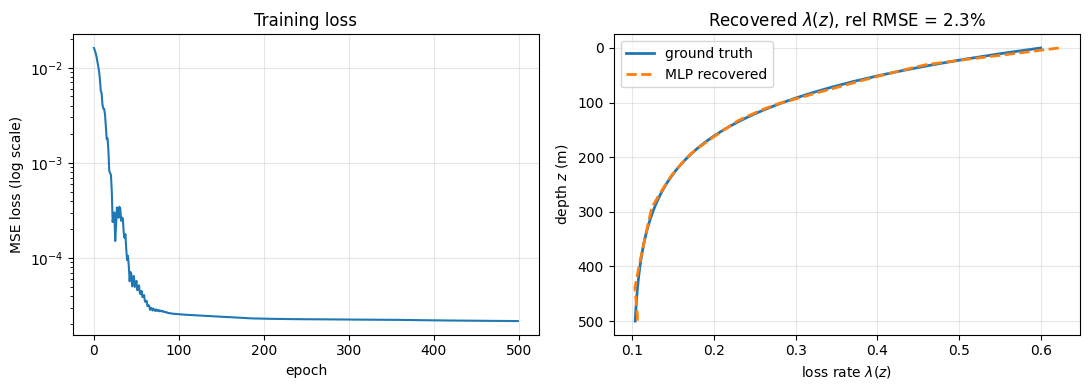

In [5]:
z_norm = ((z - z.mean()) / z.std()).to(device)
features = z_norm.unsqueeze(-1)
with torch.no_grad():
    lambda_pred = mlp(features).cpu()

rel_rmse = (
    (lambda_pred - lambda_true).pow(2).mean().sqrt() / lambda_true.mean()
).item()
print(f"Relative RMSE on lambda(z): {rel_rmse * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(losses)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss (log scale)")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(lambda_true, z, label="ground truth", linewidth=2)
axes[1].plot(lambda_pred, z, "--", label="MLP recovered", linewidth=2)
axes[1].invert_yaxis()
axes[1].set_xlabel(r"loss rate $\lambda(z)$")
axes[1].set_ylabel(r"depth $z$ (m)")
axes[1].set_title(f"Recovered $\\lambda(z)$, rel RMSE = {rel_rmse * 100:.1f}%")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## What this proves

If the recovered curve tracks the ground truth and the relative RMSE is small (under 10%), three things are empirically confirmed on the actual hardware:

1. **Autograd flows correctly through hand-coded numerical integration.** The 200-step time loop does not break the gradient graph.
2. **The MLP + physics composition is stable for gradient descent.** Loss decreases monotonically without numerical blow-up.
3. **The inverse problem converges.** Gradient descent recovers an unknown spatially-varying parameter from noisy observations of the simulator output.

This is the BINN-style validation pattern (Xu et al. 2025, arXiv:2502.00672). The same scaffold transfers to real ECCO-Darwin biogeochemistry once the equation subset and parameter targets are locked with the domain advisor — only the physics module is swapped, the MLP and recovery loop stay the same.